# Task 4: Hydrogen Tweet Classification with BERT

In [27]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, accuracy_score
torch.cuda.empty_cache()

In [2]:
#pip install ipywidgets

In [3]:
#pip install transformers

In [4]:
#pip install datasets

In [5]:
#pip install 'accelerate>=0.26.0'

In [6]:
df = pd.read_csv("Datasets/hydrogen_small.csv")
print(df.head())

# Convert labels to integers
df['label'] = df['label'].map({'Relevant': 1, 'Irrelevant': 0})

# Train-test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("Full distribution (counts):")
print(df["label"].value_counts(dropna=False))

        label                                               text
0    Relevant         behind the wheel of a hydrogen powered car
1  Irrelevant  mls measurements of stratospheric hydrogen cya...
2    Relevant  ana gonzalez hernandez shares an overview of h...
3    Relevant  toyota is giving away its first hydrogen car i...
4    Relevant  agility develops storage systems for hydrogen ...
Train size: 800
Test size: 200
Full distribution (counts):
label
1    547
0    453
Name: count, dtype: int64


First model

Preparing the datasets

In [7]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",  
        max_length=max_len
    )

In [8]:
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
test_ds  = Dataset.from_pandas(test_df,  preserve_index=False)

model_name = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_len = tokenizer.model_max_length

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize,  batched=True, remove_columns=["text"])

train_ds = train_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [9]:
# Loading the first model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    problem_type="single_label_classification"
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    prec, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="binary", pos_label=1)
    return {
    "accuracy": acc,
    "precision": prec,
    "recall": recall,
    "f1": f1
    }

Training

In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",          
    save_strategy="epoch",
    load_best_model_at_end=True,         
    metric_for_best_model="eval_f1",     
    greater_is_better=True,               
    fp16=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
)

In [12]:
model.train()
trainer = Trainer(
model=model,
args=training_args,
train_dataset=train_ds,
eval_dataset=test_ds,
processing_class=tokenizer,
data_collator=DataCollatorWithPadding(tokenizer),
compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.233100,0.675581,0.860000,0.809160,0.972477,0.883333
2,0.552500,0.356748,0.930000,0.920354,0.954128,0.936937
3,0.130800,0.464911,0.925000,0.919643,0.944954,0.932127
4,0.016700,0.513731,0.920000,0.911504,0.944954,0.927928
5,0.004900,0.605149,0.910000,0.888889,0.954128,0.920354


TrainOutput(global_step=1000, training_loss=0.21166791149973868, metrics={'train_runtime': 163.7872, 'train_samples_per_second': 24.422, 'train_steps_per_second': 6.105, 'total_flos': 529869594624000.0, 'train_loss': 0.21166791149973868, 'epoch': 5.0})

In [13]:
model.eval()
train_results1 = trainer.evaluate(train_ds)
test_results1 = trainer.evaluate(test_ds)

def display_evaluation(setname, results):
    print(f"{setname} Set Accuracy:", round(results["eval_accuracy"], 3))
    print(f"{setname} Set Precision:", round(results["eval_precision"], 3))
    print(f"{setname} Set Recall:", round(results["eval_recall"], 3))
    print(f"{setname} Set F1 score:", round(results["eval_f1"], 3))
    
display_evaluation("Training", train_results1)
display_evaluation("Testing", test_results1)

Training Set Accuracy: 0.98
Training Set Precision: 0.977
Training Set Recall: 0.986
Training Set F1 score: 0.982
Testing Set Accuracy: 0.93
Testing Set Precision: 0.92
Testing Set Recall: 0.954
Testing Set F1 score: 0.937


Second model

Prepare data

In [14]:
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
test_ds  = Dataset.from_pandas(test_df,  preserve_index=False)

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_len = tokenizer.model_max_length

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize,  batched=True, remove_columns=["text"])

train_ds = train_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch",  columns=["input_ids", "attention_mask", "labels"])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [15]:
# Loading the second model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    problem_type="single_label_classification"
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",          
    save_strategy="epoch",
    load_best_model_at_end=True,         
    metric_for_best_model="eval_f1",     
    greater_is_better=True,               
    fp16=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
)

In [17]:
model.train()
trainer = Trainer(
model=model,
args=training_args,
train_dataset=train_ds,
eval_dataset=test_ds,
processing_class=tokenizer,
data_collator=DataCollatorWithPadding(tokenizer),
compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.232500,0.394249,0.885000,0.877193,0.917431,0.896861
2,0.444600,0.333188,0.925000,0.943396,0.917431,0.930233
3,0.007100,0.481598,0.905000,0.875000,0.963303,0.917031
4,0.001600,0.495502,0.910000,0.882353,0.963303,0.921053
5,0.112400,0.500442,0.910000,0.882353,0.963303,0.921053


TrainOutput(global_step=1000, training_loss=0.16129819840192794, metrics={'train_runtime': 151.1158, 'train_samples_per_second': 26.47, 'train_steps_per_second': 6.617, 'total_flos': 529869594624000.0, 'train_loss': 0.16129819840192794, 'epoch': 5.0})

In [18]:
model.eval()
train_results2 = trainer.evaluate(train_ds)
test_results2 = trainer.evaluate(test_ds)

display_evaluation("Training", train_results2)
display_evaluation("Testing", test_results2)

Training Set Accuracy: 0.978
Training Set Precision: 0.995
Training Set Recall: 0.963
Training Set F1 score: 0.979
Testing Set Accuracy: 0.925
Testing Set Precision: 0.943
Testing Set Recall: 0.917
Testing Set F1 score: 0.93


Attention Weights

DistilBertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


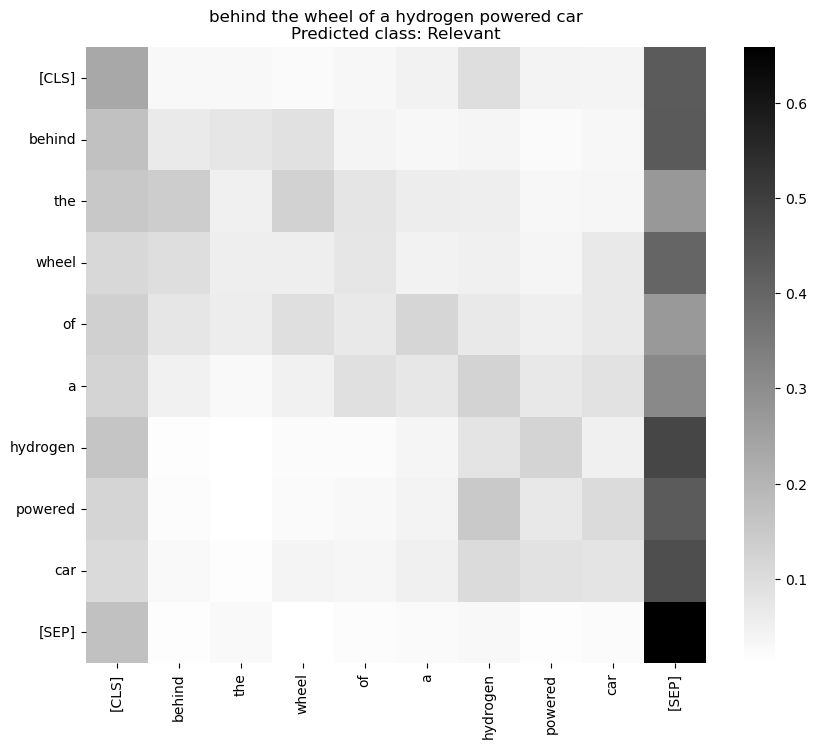

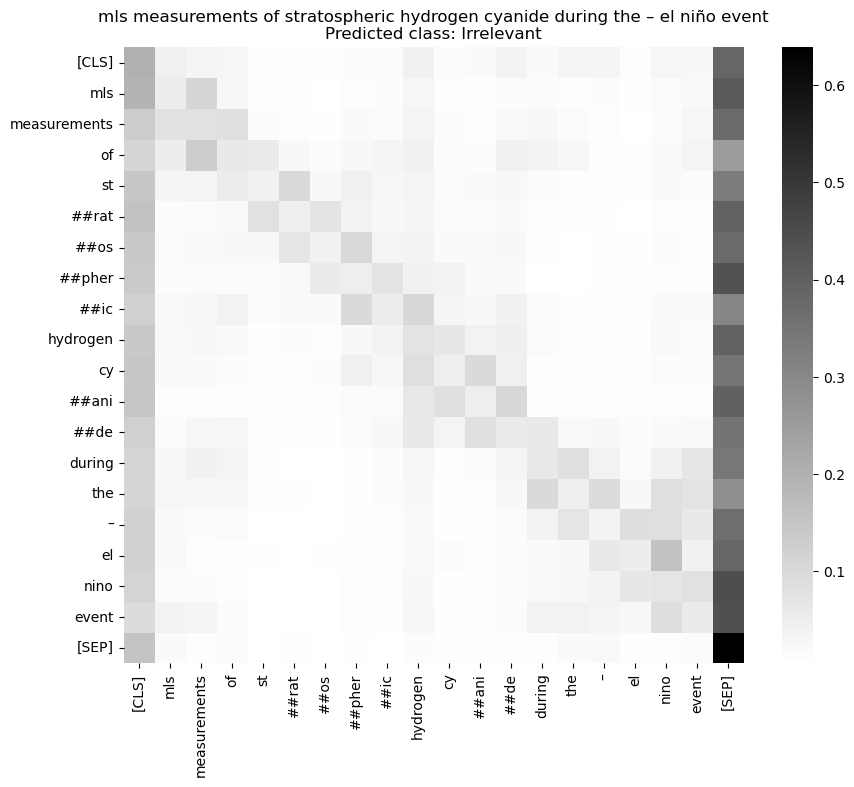

In [20]:
def compute_attention_matrix(tokenizer, model, text):
    tokens = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**tokens, output_attentions=True)
    attentions = torch.stack(outputs.attentions).cpu()
    attentions = attentions.squeeze(1)
    attentions = attentions.mean(dim=0).mean(dim=0)
    pred_class = outputs.logits.cpu().argmax(-1).item()
    token_strs = tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])
    return attentions, pred_class, token_strs

def plot_attention(attentions, tokens, title):
    plt.figure(figsize=(10, 8))
    plt.title(title)
    sns.heatmap(
        attentions,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='binary',
        cbar=True
    )
    plt.xticks(rotation=90)
    plt.show()

def display_attention_matrix(tokenizer, model, text):
    attentions, pred_class, tokens = compute_attention_matrix(tokenizer, model, text)
    pred_label = "Relevant" if pred_class == 1 else "Irrelevant"
    plot_attention(attentions, tokens, text + f"\nPredicted class: {pred_label}")

relevant_text = df[df["label"] == 1].iloc[0]["text"]
display_attention_matrix(tokenizer, model, relevant_text)

irrelevant_text = df[df["label"] == 0].iloc[0]["text"]
display_attention_matrix(tokenizer, model, irrelevant_text)


Logistic regression model

In [25]:
X = pd.read_csv("Datasets/tfidf_features_small.csv")
labels_df = pd.read_csv("Datasets/hydrogen_small.csv")

y = labels_df["label"].map({'Relevant': 1, 'Irrelevant': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


ROC curves

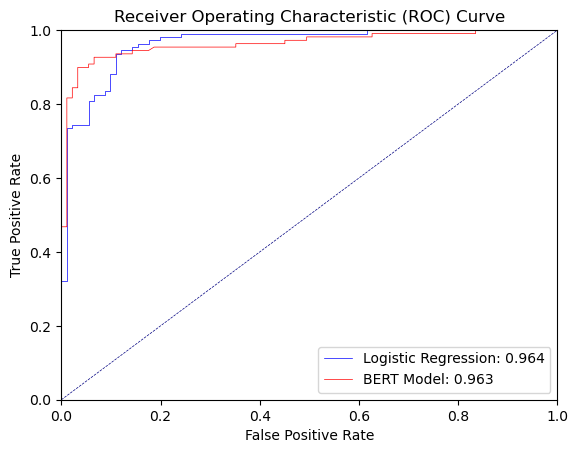

In [31]:
# LR
logit_probs = clf.predict_proba(X_test)[:, 1]  
y_pred = clf.predict(X_test)                   
y_test_lr = y_test.values                      
roc_index_lr = roc_auc_score(y_test_lr, logit_probs)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_lr, logit_probs)

# BERT
pred = trainer.predict(test_ds)
bert_probs = torch.nn.functional.softmax(torch.Tensor(pred.predictions), dim=-1).numpy()
bert_pred_labels = np.argmax(pred.predictions, axis=-1)
y_test_bert = pred.label_ids
roc_index_bert = roc_auc_score(y_test_bert, bert_probs[:, 1])
fpr_bert, tpr_bert, thresholds_bert = roc_curve(y_test_bert, bert_probs[:, 1])

# Plot ROC curves
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression: {:.3f}".format(roc_index_lr), color="blue", lw=0.5)
plt.plot(fpr_bert, tpr_bert, label="BERT Model: {:.3f}".format(roc_index_bert), color="red", lw=0.5)
plt.plot([0, 1], [0, 1], color="navy", lw=0.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

In [35]:
# Compare both models with an accuracy table
accuracy_lr = accuracy_score(y_test_lr, y_pred)
accuracy_bert = accuracy_score(y_test_bert, bert_pred_labels)

print("\nAccuracy Table")
print("{:<24} {:<12} {:<10}".format("Model", "Accuracy", "AUC-ROC"))
print("{:<24} {:.3f}        {:.3f}".format("Logistic Regression", accuracy_lr, roc_index_lr))
print("{:<24} {:.3f}        {:.3f}".format("BERT Model", accuracy_bert, roc_index_bert))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test_lr, y_pred, target_names=["Irrelevant", "Relevant"]))

print("\nBERT Model Classification Report:")
print(classification_report(y_test_bert, bert_pred_labels, target_names=["Irrelevant", "Relevant"]))



Accuracy Table
Model                    Accuracy     AUC-ROC   
Logistic Regression      0.910        0.964
BERT Model               0.925        0.963

Logistic Regression Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.95      0.85      0.90        91
    Relevant       0.88      0.96      0.92       109

    accuracy                           0.91       200
   macro avg       0.92      0.90      0.91       200
weighted avg       0.91      0.91      0.91       200


BERT Model Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.90      0.93      0.92        91
    Relevant       0.94      0.92      0.93       109

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200



# Prepare SQuAD_tiny Dataset for Assignment 2

This code prepare SQuAD_tiny from the SQuAD dataset. 